# Land Cover Change Detection: Change Maps and Polygons

This notebook takes the 8 annual NDVI composites (2018–2025) and produces the core change-detection products:
pairwise NDVI deltas, per-pixel z-scores, a thresholded change mask, and a vectorized GeoPackage of
change polygons attributed with area, direction (gain/loss), and the year the biggest shift occurred.

No dask — everything fits comfortably in RAM as numpy arrays (~2.5 GB for the 8-year stack).

**Inputs:** `data/composites/ndvi_2018.tif` through `ndvi_2025.tif` (band 1: median NDVI float32)  
**Outputs:** `data/change/` — 7 delta TIFs, 8 z-score TIFs, total change, max-change-year, mean/std;  
and `data/change_polygons.gpkg` — vectorized, attributed, filtered change polygons

In [1]:
import gc
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import rasterio.features
import rasterio.transform
from matplotlib.patches import Patch
from scipy.ndimage import binary_opening
from scipy.ndimage import label as ndimage_label
from shapely.geometry import Point, shape

warnings.filterwarnings("ignore")

DATA_DIR      = Path("data")
COMPOSITES_DIR = DATA_DIR / "composites"
CHANGE_DIR    = DATA_DIR / "change"
CHANGE_DIR.mkdir(exist_ok=True)

YEARS      = list(range(2018, 2026))
YEAR_PAIRS = [(YEARS[i], YEARS[i + 1]) for i in range(7)]

## Load Composites

Read the NDVI band (band 1) from each composite into a single `(8, H, W)` float32 array.
The rasterio profile from the first file is kept to use when writing output TIFs — it captures the
CRS (EPSG:5070), affine transform, and spatial extent that all outputs must share.

In [2]:
aoi_5070 = gpd.read_file(DATA_DIR / "gsmnp_aoi.gpkg")

with rasterio.open(COMPOSITES_DIR / "ndvi_2018.tif") as src:
    profile   = src.profile.copy()
    H, W      = src.height, src.width
    transform = src.transform

# Update profile for single-band float32 outputs
profile.update(count=1, dtype="float32", nodata=float("nan"), compress="lzw")

ndvi_stack = np.empty((8, H, W), dtype="float32")
for i, year in enumerate(YEARS):
    with rasterio.open(COMPOSITES_DIR / f"ndvi_{year}.tif") as src:
        ndvi_stack[i] = src.read(1)

print(f"NDVI stack shape: {ndvi_stack.shape}")
print(f"Grid: {H:,} rows × {W:,} cols at 10 m resolution")
print(f"RAM:  {ndvi_stack.nbytes / 1e9:.2f} GB")

NDVI stack shape: (8, 8018, 11890)
Grid: 8,018 rows × 11,890 cols at 10 m resolution
RAM:  3.05 GB


## Pairwise NDVI Differencing

Seven consecutive-year deltas (year N+1 minus year N) and one total-change raster (2025 minus 2018).
Positive values mean NDVI increased (greening); negative means browning. NaN propagates from either
input year, so pixels without valid data in both years are excluded from the delta.

Each delta is written to `data/change/` immediately.

In [3]:
def write_tif(path, arr, profile, description=None):
    """Write a single-band float32 GeoTIFF using an existing rasterio profile."""
    meta = profile.copy()
    meta["count"] = 1
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(arr.astype("float32"), 1)
        if description:
            dst.update_tags(1, description=description)


# Consecutive-year deltas: (7, H, W)
deltas = np.empty((7, H, W), dtype="float32")
for i, (y0, y1) in enumerate(YEAR_PAIRS):
    deltas[i] = ndvi_stack[i + 1] - ndvi_stack[i]
    write_tif(CHANGE_DIR / f"delta_{y0}_{y1}.tif", deltas[i], profile,
              f"NDVI delta {y0}\u2192{y1}")

# Total change: 2025 minus 2018
total_change = ndvi_stack[-1] - ndvi_stack[0]
write_tif(CHANGE_DIR / "total_change.tif", total_change, profile,
          "Total NDVI change 2025\u22122018")

print("Consecutive-year deltas (non-NaN pixels):")
for i, (y0, y1) in enumerate(YEAR_PAIRS):
    valid = deltas[i][~np.isnan(deltas[i])]
    print(f"  {y0}\u2192{y1}: mean={np.mean(valid):+.4f}  "
          f"loss(>0.10): {np.mean(valid < -0.10)*100:.1f}%  "
          f"gain(>0.10): {np.mean(valid > 0.10)*100:.1f}%")

valid_tc = total_change[~np.isnan(total_change)]
print(f"\nTotal change (2025\u22122018):")
print(f"  mean={np.mean(valid_tc):+.4f}  "
      f"loss: {np.mean(valid_tc < -0.10)*100:.1f}%  "
      f"gain: {np.mean(valid_tc > 0.10)*100:.1f}%")

Consecutive-year deltas (non-NaN pixels):
  2018→2019: mean=+0.0034  loss(>0.10): 2.6%  gain(>0.10): 3.6%
  2019→2020: mean=-0.0204  loss(>0.10): 8.6%  gain(>0.10): 1.4%
  2020→2021: mean=-0.0002  loss(>0.10): 4.6%  gain(>0.10): 7.5%
  2021→2022: mean=+0.0313  loss(>0.10): 3.0%  gain(>0.10): 7.0%
  2022→2023: mean=-0.0109  loss(>0.10): 2.9%  gain(>0.10): 2.3%
  2023→2024: mean=-0.0099  loss(>0.10): 4.4%  gain(>0.10): 2.5%
  2024→2025: mean=+0.0041  loss(>0.10): 3.3%  gain(>0.10): 4.1%

Total change (2025−2018):
  mean=-0.0032  loss: 6.4%  gain: 4.7%


## Delta Histograms

The distribution of NDVI change values tells us whether the threshold is in a reasonable place.
A healthy forest landscape should produce a roughly Gaussian distribution centered near zero —
year-to-year variation from phenology and cloud masking artifacts, with the tails representing
genuine change. The ±0.10 lines mark where we'll threshold later.

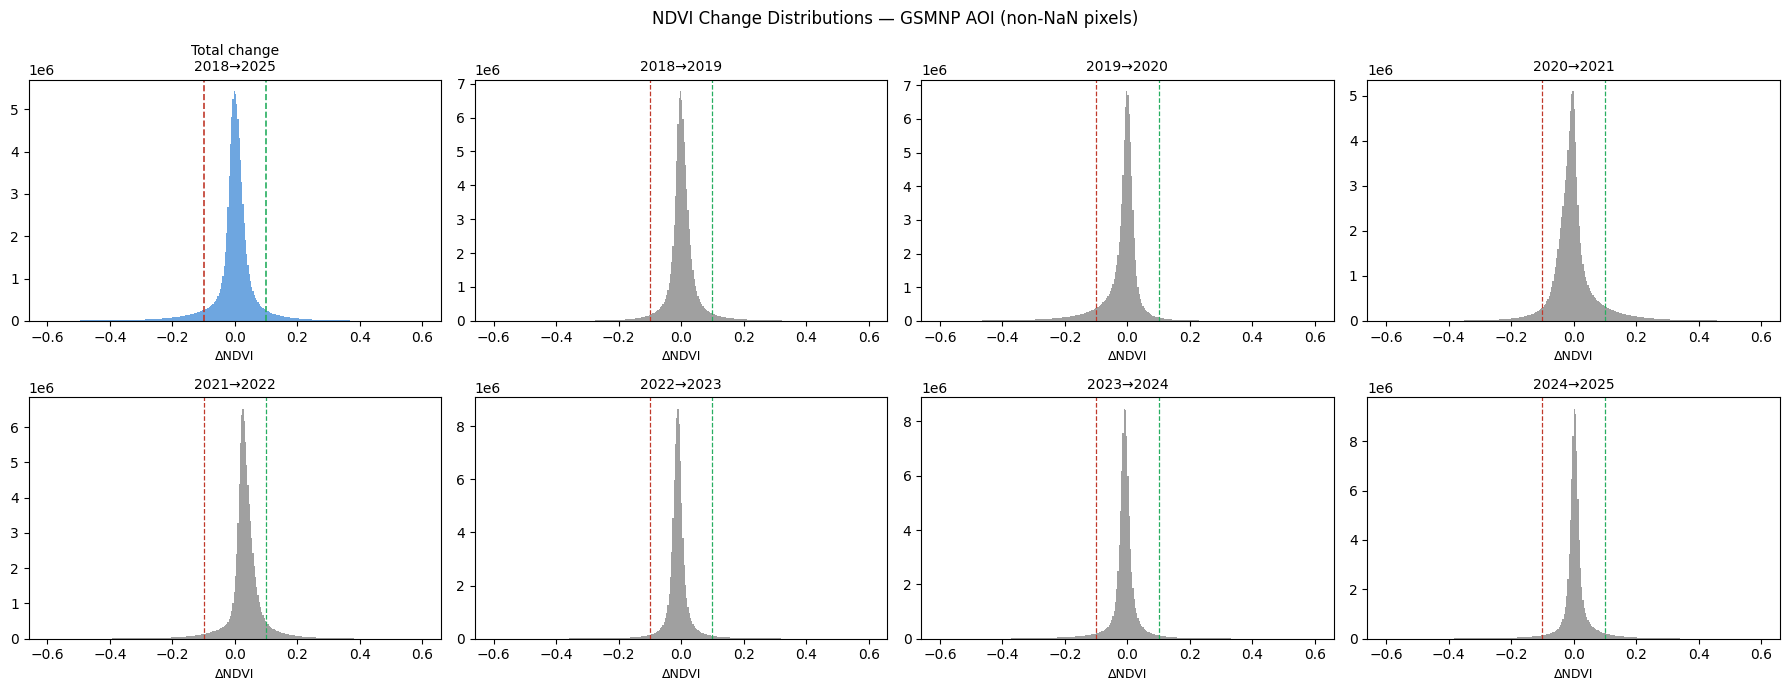

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

# Total change in the first panel
ax = axes[0]
ax.hist(valid_tc, bins=300, range=(-0.6, 0.6), color="#4a90d9", alpha=0.8, edgecolor="none")
ax.axvline(-0.10, color="#c0392b", lw=1.2, ls="--")
ax.axvline( 0.10, color="#27ae60", lw=1.2, ls="--")
ax.set_title("Total change\n2018\u21922025", fontsize=10)
ax.set_xlabel("\u0394NDVI", fontsize=9)

for ax, (i, (y0, y1)) in zip(axes[1:], enumerate(YEAR_PAIRS)):
    valid = deltas[i][~np.isnan(deltas[i])]
    ax.hist(valid, bins=300, range=(-0.6, 0.6), color="#888", alpha=0.8, edgecolor="none")
    ax.axvline(-0.10, color="#c0392b", lw=0.9, ls="--")
    ax.axvline( 0.10, color="#27ae60", lw=0.9, ls="--")
    ax.set_title(f"{y0}\u2192{y1}", fontsize=10)
    ax.set_xlabel("\u0394NDVI", fontsize=9)

fig.suptitle("NDVI Change Distributions — GSMNP AOI (non-NaN pixels)", fontsize=12)
plt.tight_layout()
plt.show()

## Per-Pixel Z-Scores

The z-score for a given pixel-year is how many standard deviations that year's NDVI is from the
pixel's 8-year mean. Values with |z| > 2 are anomalous relative to the pixel's own history.
This complements the threshold approach: an absolute delta of 0.10 matters more in a stable pixel
(low std) than in a volatile one (high std).

Pixels where std is zero across all 8 years (perfectly stable — rare) get NaN to avoid division by zero.

In [5]:
ndvi_mean = np.nanmean(ndvi_stack, axis=0)
ndvi_std  = np.nanstd(ndvi_stack,  axis=0)

write_tif(CHANGE_DIR / "ndvi_mean.tif", ndvi_mean, profile, "8-year mean NDVI (2018\u20132025)")
write_tif(CHANGE_DIR / "ndvi_std.tif",  ndvi_std,  profile, "8-year NDVI std dev (2018\u20132025)")

with np.errstate(divide="ignore", invalid="ignore"):
    for i, year in enumerate(YEARS):
        z = np.where(ndvi_std > 0, (ndvi_stack[i] - ndvi_mean) / ndvi_std, np.nan)
        write_tif(CHANGE_DIR / f"zscore_{year}.tif", z.astype("float32"), profile,
                  f"NDVI z-score {year}")

print(f"Mean NDVI range: {np.nanmin(ndvi_mean):.3f} \u2013 {np.nanmax(ndvi_mean):.3f}")
print(f"Std dev range:   {np.nanmin(ndvi_std[ndvi_std > 0]):.3f} \u2013 {np.nanmax(ndvi_std):.3f}")
print(f"Wrote ndvi_mean.tif, ndvi_std.tif, and {len(YEARS)} zscore_YYYY.tif files")

Mean NDVI range: -1.000 – 0.930
Std dev range:   0.000 – 0.730
Wrote ndvi_mean.tif, ndvi_std.tif, and 8 zscore_YYYY.tif files


In [6]:
del ndvi_mean, ndvi_std, ndvi_stack
gc.collect()

15

## Year of Maximum Absolute Change

For each pixel, which consecutive-year transition had the largest absolute NDVI shift?
This is the most useful single-number attribution for change polygons — it tells you *when*
the landscape shifted, not just that it did. Encoded as the start year of the transition
(e.g., value 2022 means the 2022→2023 delta was the largest).

## Resume Point

If the kernel was restarted after the delta and total-change TIFs were already written,
run Cell 1 (imports) then this cell to reconstruct the in-memory state without
reloading the full NDVI composite stack.

In [2]:
def write_tif(path, arr, profile, description=None):
    meta = profile.copy()
    meta["count"] = 1
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(arr.astype("float32"), 1)
        if description:
            dst.update_tags(1, description=description)

aoi_5070 = gpd.read_file(DATA_DIR / "gsmnp_aoi.gpkg")

# Spatial metadata from any existing delta TIF
with rasterio.open(CHANGE_DIR / "delta_2018_2019.tif") as src:
    profile   = src.profile.copy()
    H, W      = src.height, src.width
    transform = src.transform

# Reload the 7 consecutive-year deltas
deltas = np.empty((7, H, W), dtype="float32")
for i, (y0, y1) in enumerate(YEAR_PAIRS):
    with rasterio.open(CHANGE_DIR / f"delta_{y0}_{y1}.tif") as src:
        deltas[i] = src.read(1)

with rasterio.open(CHANGE_DIR / "total_change.tif") as src:
    total_change = src.read(1)

valid_tc = total_change[~np.isnan(total_change)]
print(f"Loaded deltas: {deltas.shape}, total_change: {total_change.shape}")
print(f"Grid: {H:,} x {W:,}")

Loaded deltas: (7, 8018, 11890), total_change: (8018, 11890)
Grid: 8,018 x 11,890


In [3]:
# Replace NaN with -inf so argmax always picks a real value where any delta exists
abs_deltas = np.abs(deltas)
filled     = np.where(np.isnan(abs_deltas), -np.inf, abs_deltas)
max_idx    = np.argmax(filled, axis=0)  # (H, W), values 0–6
del filled

# Magnitude and year for the dominant transition, via advanced indexing
rows_idx = np.arange(H)[:, None]  # (H, 1) — broadcasts over W
cols_idx = np.arange(W)[None, :]  # (1, W) — broadcasts over H
max_abs_delta_arr = abs_deltas[max_idx, rows_idx, cols_idx].astype("float32")

# Encode as the start year of the pair with the largest change
start_years = np.array([y0 for y0, _ in YEAR_PAIRS], dtype="float32")
max_change_year_arr = start_years[max_idx].astype("float32")

# Mask pixels where every transition was NaN (boundary fringe or persistent cloud)
all_deltas_nan = np.all(np.isnan(abs_deltas), axis=0)
max_change_year_arr = np.where(all_deltas_nan, np.nan, max_change_year_arr)
max_abs_delta_arr   = np.where(all_deltas_nan, np.nan, max_abs_delta_arr)

write_tif(CHANGE_DIR / "max_change_year.tif", max_change_year_arr, profile,
          "Start year of the transition with the largest absolute NDVI delta")
write_tif(CHANGE_DIR / "max_abs_delta.tif", max_abs_delta_arr, profile,
          "Magnitude of the largest single-year NDVI delta")

valid_mcy = max_change_year_arr[~np.isnan(max_change_year_arr)]
print("Year of maximum absolute change (share of valid pixels):")
for y0, y1 in YEAR_PAIRS:
    pct = np.mean(valid_mcy == y0) * 100
    print(f"  {y0}\u2192{y1}: {pct:.1f}%")

del deltas, max_idx
gc.collect()

Year of maximum absolute change (share of valid pixels):
  2018→2019: 12.1%
  2019→2020: 12.6%
  2020→2021: 10.3%
  2021→2022: 41.6%
  2022→2023: 7.9%
  2023→2024: 7.9%
  2024→2025: 7.6%


20

## Threshold and Morphological Cleaning

The change mask applies `|total NDVI change| > 0.10` — a standard threshold for ecologically
significant NDVI shifts at 10 m resolution. This is applied to the 8-year total (2025 minus 2018)
rather than any single year, which reduces sensitivity to one-year phenological anomalies.

Morphological opening (erosion followed by dilation with a 3×3 structuring element) removes
isolated single pixels that pass the threshold due to compositing artifacts or SCL misclassification.
Any real land cover change in this landscape is at least a few pixels in extent.

In [4]:
change_mask = (np.abs(total_change) > 0.10) & ~np.isnan(total_change)

struct       = np.ones((3, 3), dtype=bool)
cleaned_mask = binary_opening(change_mask, structure=struct)

pixel_area_ha = 100 / 10_000  # 10 m × 10 m = 100 m² = 0.01 ha
n_raw     = int(change_mask.sum())
n_cleaned = int(cleaned_mask.sum())
n_gain    = int(((total_change >  0.10) & cleaned_mask).sum())
n_loss    = int(((total_change < -0.10) & cleaned_mask).sum())
total_aoi_ha = H * W * pixel_area_ha

print(f"Raw change pixels (|\u0394| > 0.10): {n_raw:,}  ({n_raw * pixel_area_ha:,.0f} ha)")
print(f"After morphological opening:     {n_cleaned:,}  ({n_cleaned * pixel_area_ha:,.0f} ha)")
print(f"  Gain (greening): {n_gain:,}  ({n_gain * pixel_area_ha:,.0f} ha)")
print(f"  Loss (browning): {n_loss:,}  ({n_loss * pixel_area_ha:,.0f} ha)")
print(f"  Changed area: {n_cleaned * pixel_area_ha / 100:.1f} km\u00b2  "
      f"({n_cleaned / (H * W) * 100:.1f}% of AOI grid extent)")

Raw change pixels (|Δ| > 0.10): 10,306,007  (103,060 ha)
After morphological opening:     5,860,844  (58,608 ha)
  Gain (greening): 2,320,951  (23,210 ha)
  Loss (browning): 3,539,893  (35,399 ha)
  Changed area: 586.1 km²  (6.1% of AOI grid extent)


## Vectorize and Attribute Change Polygons

Connected components of the cleaned change mask become individual polygons.

`scipy.ndimage.label` assigns a unique integer to each connected component, then
`rasterio.features.shapes` converts each labeled region to a vector polygon in EPSG:5070.
Polygon statistics — mean delta, max single-year delta, dominant change year — are computed
by grouping the underlying pixel arrays by label with pandas. This avoids re-rasterizing each
polygon and is fast even for tens of thousands of components.

In [5]:
labeled, n_components = ndimage_label(cleaned_mask)
print(f"Connected components (pre-filter): {n_components:,}")

# Geometry per component via rasterio.features.shapes on the labeled int32 array
shapes_list = list(rasterio.features.shapes(
    labeled.astype(np.int32),
    mask=(labeled > 0).astype(np.uint8),
    transform=transform,
))
geoms_df = pd.DataFrame(
    [{"label": int(val), "geometry": shape(geom)} for geom, val in shapes_list]
)

# Pixel-level statistics for attribution — build once, groupby label
flat_labels = labeled.ravel()
valid_px    = flat_labels > 0
pixel_df = pd.DataFrame({
    "label":           flat_labels[valid_px],
    "total_change":    total_change.ravel()[valid_px],
    "max_abs_delta":   max_abs_delta_arr.ravel()[valid_px],
    "max_change_year": max_change_year_arr.ravel()[valid_px],
})

def modal_year(x):
    """Mode of max_change_year, with NaN-safe fallback."""
    valid = x.dropna()
    return valid.mode().iloc[0] if len(valid) > 0 else np.nan

stats_df = pixel_df.groupby("label").agg(
    pixel_count    =("total_change",    "count"),
    mean_delta     =("total_change",    "mean"),
    max_abs_delta  =("max_abs_delta",   "max"),
    max_change_year=("max_change_year", modal_year),
).reset_index()

stats_df["area_ha"]   = stats_df["pixel_count"] * pixel_area_ha
stats_df["direction"] = np.where(stats_df["mean_delta"] > 0, "gain", "loss")

gdf = gpd.GeoDataFrame(
    stats_df.merge(geoms_df, on="label"),
    geometry="geometry",
    crs="EPSG:5070",
)

print(f"GeoDataFrame: {len(gdf):,} polygons")
print(f"  Median area: {gdf['area_ha'].median():.2f} ha")
print(f"  Max area:    {gdf['area_ha'].max():.1f} ha")

del labeled, shapes_list, flat_labels, pixel_df, stats_df, geoms_df
gc.collect()

Connected components (pre-filter): 77,497
GeoDataFrame: 77,497 polygons
  Median area: 0.19 ha
  Max area:    1012.2 ha


0

## Filter and Simplify

Drop polygons smaller than 0.5 ha (50 pixels at 10 m). At Sentinel-2 resolution, anything smaller
is below the reliable detection limit and is more likely an SCL artefact than a real change event.

Geometry simplification at 20 m tolerance keeps shapes recognizable in a web map while substantially
reducing vertex count. `preserve_topology=True` prevents self-intersections.

In [6]:
gdf_filtered = gdf[gdf["area_ha"] >= 0.5].copy()
print(f"After \u22650.5 ha filter: {len(gdf_filtered):,} polygons  "
      f"(dropped {len(gdf) - len(gdf_filtered):,})")

gdf_filtered["geometry"] = gdf_filtered.geometry.simplify(20, preserve_topology=True)

gain_count = (gdf_filtered["direction"] == "gain").sum()
loss_count = (gdf_filtered["direction"] == "loss").sum()
total_area = gdf_filtered["area_ha"].sum()

print(f"\nFinal inventory:")
print(f"  Total:  {len(gdf_filtered):,} polygons  ({total_area:,.0f} ha)")
print(f"  Gain:   {gain_count:,} polygons  "
      f"({gdf_filtered.loc[gdf_filtered['direction']=='gain','area_ha'].sum():,.0f} ha)")
print(f"  Loss:   {loss_count:,} polygons  "
      f"({gdf_filtered.loc[gdf_filtered['direction']=='loss','area_ha'].sum():,.0f} ha)")

out_path = DATA_DIR / "change_polygons.gpkg"
gdf_filtered.to_file(out_path, driver="GPKG")
print(f"\nSaved \u2192 {out_path}  ({out_path.stat().st_size / 1e6:.1f} MB)")

print("\nChange raster inventory:")
for f in sorted(CHANGE_DIR.iterdir()):
    print(f"  {f.name:<40s}  {f.stat().st_size / 1e6:.1f} MB")

After ≥0.5 ha filter: 17,562 polygons  (dropped 59,935)

Final inventory:
  Total:  17,562 polygons  (47,630 ha)
  Gain:   6,678 polygons  (18,787 ha)
  Loss:   10,884 polygons  (28,843 ha)

Saved → data/change_polygons.gpkg  (7.7 MB)

Change raster inventory:
  delta_2018_2019.tif                       401.0 MB
  delta_2019_2020.tif                       398.5 MB
  delta_2020_2021.tif                       401.4 MB
  delta_2021_2022.tif                       393.2 MB
  delta_2022_2023.tif                       380.3 MB
  delta_2023_2024.tif                       386.4 MB
  delta_2024_2025.tif                       392.1 MB
  max_abs_delta.tif                         399.6 MB
  max_change_year.tif                       39.0 MB
  ndvi_mean.tif                             394.8 MB
  ndvi_std.tif                              430.3 MB
  total_change.tif                          401.1 MB
  zscore_2018.tif                           456.7 MB
  zscore_2019.tif                           457.1 M

## Diagnostic Maps

Three panels showing the change signal from different angles:

1. **Total change** (2025 − 2018): diverging colormap, green = gain, red = loss. Pixels close to zero
   in the grey band are stable.
2. **Year of maximum absolute change**: which transition year drove the most change at each pixel.
   Clusters of the same color indicate a region-wide event (fire, storm, beetle outbreak, development).
3. **Change polygons on 2025 NDVI**: the filtered, vectorized change areas overlaid on the most
   recent composite.

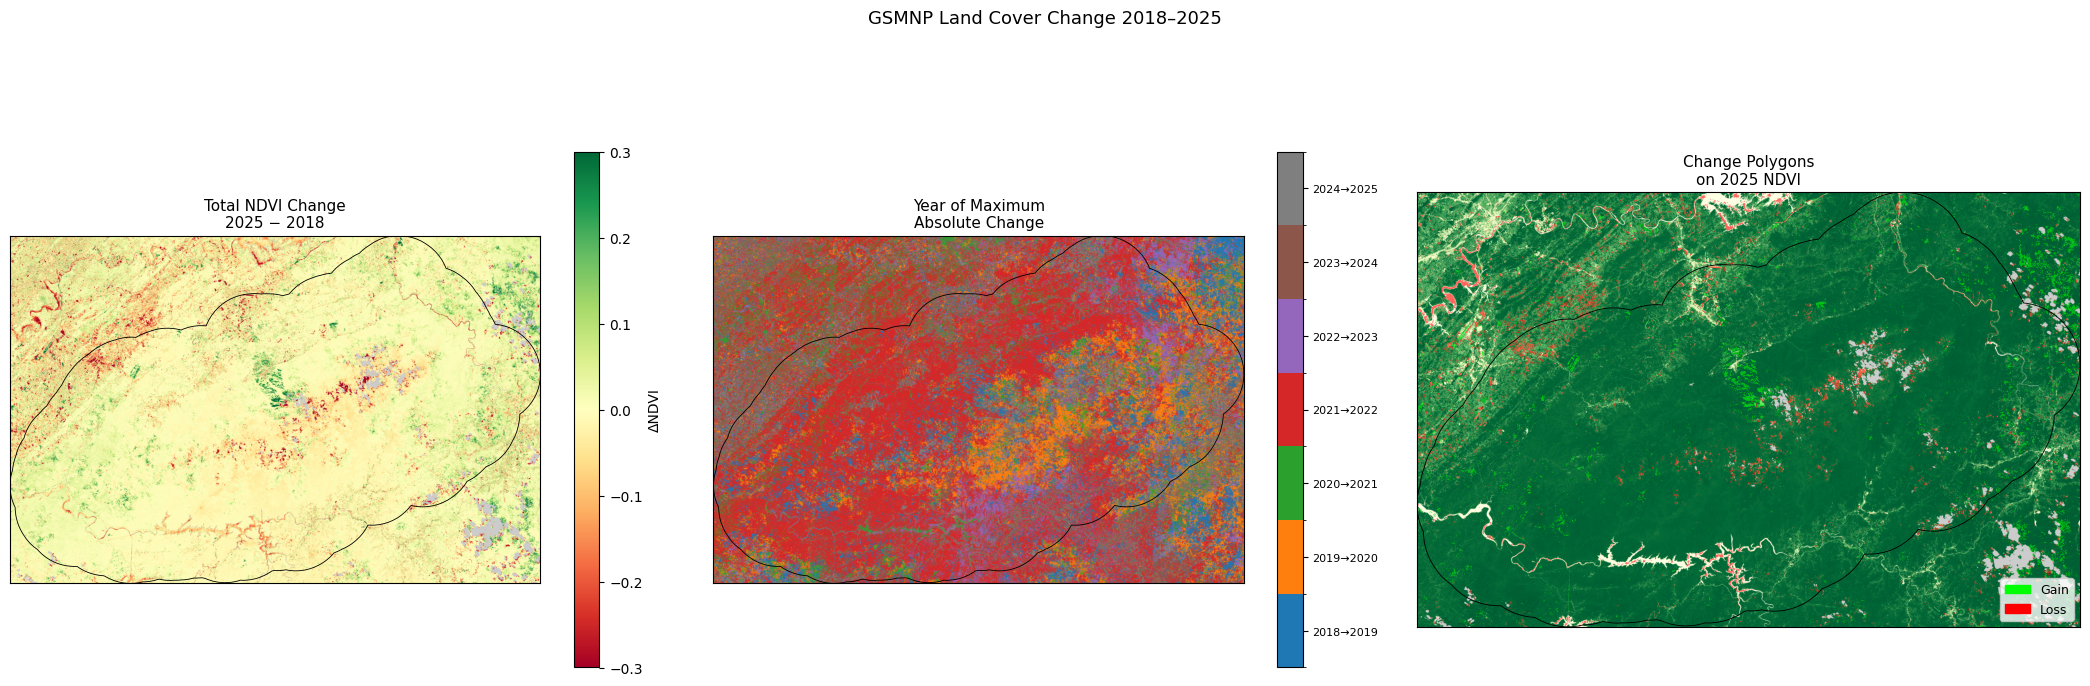

In [7]:
xmin, ymin, xmax, ymax = aoi_5070.total_bounds
S = 4  # downsample factor — reduces matplotlib buffer by 16x with no visible loss

fig, axes = plt.subplots(1, 3, figsize=(21, 8))

# --- Panel 1: Total change ---
ax = axes[0]
with rasterio.open(CHANGE_DIR / "total_change.tif") as src:
    tc_arr  = src.read(1)[::S, ::S]
    extent1 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
cmap_div = plt.cm.RdYlGn.copy()
cmap_div.set_bad("#cccccc")
ax.set_facecolor("#cccccc")
im1 = ax.imshow(tc_arr, cmap=cmap_div, vmin=-0.3, vmax=0.3, extent=extent1, origin="upper")
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
aoi_5070.boundary.plot(ax=ax, color="black", linewidth=0.6)
plt.colorbar(im1, ax=ax, shrink=0.7, label="\u0394NDVI")
ax.set_title("Total NDVI Change\n2025 \u2212 2018", fontsize=11)
ax.set_xticks([]); ax.set_yticks([])

# --- Panel 2: Year of max change ---
ax = axes[1]
with rasterio.open(CHANGE_DIR / "max_change_year.tif") as src:
    mcy_arr = src.read(1)[::S, ::S]
    extent2 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
year_vals  = [y0 for y0, _ in YEAR_PAIRS]   # 2018 – 2024
colors7    = plt.cm.tab10(np.linspace(0, 0.7, 7))
cmap_cat   = mcolors.ListedColormap(colors7)
bounds_cat = [y - 0.5 for y in year_vals] + [year_vals[-1] + 0.5]
norm_cat   = mcolors.BoundaryNorm(bounds_cat, cmap_cat.N)
cmap_cat.set_bad("#cccccc")
ax.set_facecolor("#cccccc")
im2 = ax.imshow(mcy_arr, cmap=cmap_cat, norm=norm_cat, extent=extent2, origin="upper")
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
aoi_5070.boundary.plot(ax=ax, color="black", linewidth=0.6)
cb2 = plt.colorbar(im2, ax=ax, shrink=0.7, ticks=year_vals)
cb2.set_ticklabels([f"{y}\u2192{y+1}" for y in year_vals])
cb2.ax.tick_params(labelsize=8)
ax.set_title("Year of Maximum\nAbsolute Change", fontsize=11)
ax.set_xticks([]); ax.set_yticks([])

# --- Panel 3: Change polygons on 2025 NDVI ---
ax = axes[2]
with rasterio.open(COMPOSITES_DIR / "ndvi_2025.tif") as src:
    ndvi25  = src.read(1)[::S, ::S]
    extent3 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
cmap_ndvi = plt.cm.YlGn.copy()
cmap_ndvi.set_bad("#cccccc")
ax.set_facecolor("#cccccc")
ax.imshow(ndvi25, cmap=cmap_ndvi, vmin=0, vmax=1, extent=extent3, origin="upper")
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

gain_polys = gdf_filtered[gdf_filtered["direction"] == "gain"]
loss_polys  = gdf_filtered[gdf_filtered["direction"] == "loss"]
if len(gain_polys):
    gain_polys.plot(ax=ax, color="lime",  alpha=0.6, edgecolor="none")
if len(loss_polys):
    loss_polys.plot(ax=ax, color="red",   alpha=0.6, edgecolor="none")
aoi_5070.boundary.plot(ax=ax, color="black", linewidth=0.6)
ax.legend(
    handles=[Patch(color="lime", label="Gain"), Patch(color="red", label="Loss")],
    loc="lower right", fontsize=9,
)
ax.set_title("Change Polygons\non 2025 NDVI", fontsize=11)
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("GSMNP Land Cover Change 2018\u20132025", fontsize=13)
plt.tight_layout()
plt.show()

## Chimney Tops 2 Fire Scar Validation

The Chimney Tops 2 fire burned approximately 4,500 ha near Gatlinburg, TN in November 2016 — the
largest and most destructive wildfire in GSMNP history. Our record starts in 2018 (two growing seasons
post-fire), so we should see a greening trend in the burn area as pioneer vegetation and young shrubs
recolonize the disturbed soil.

This is a domain validation check: if the fire recovery signal is visible as a rising NDVI trend
over 2018–2025 centered on ~35.68°N, 83.48°W, the change detection pipeline is capturing real
ecological dynamics.

Fire center pixel: row=3497, col=6091


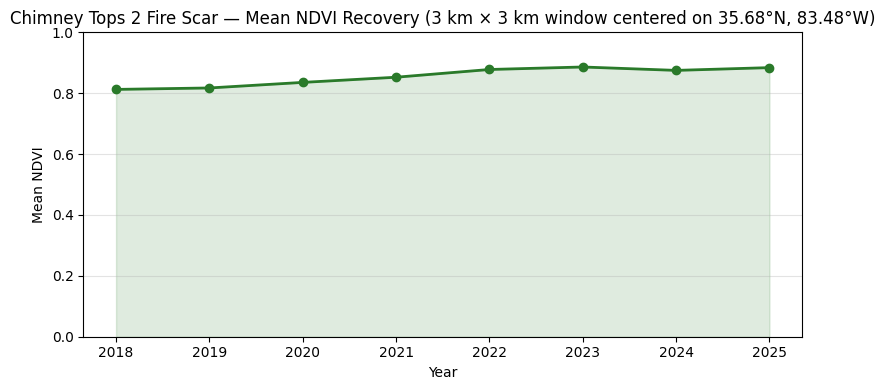

NDVI at fire scar center:
  2018: 0.813  ████████████████████████
  2019: 0.817  ████████████████████████
  2020: 0.836  █████████████████████████
  2021: 0.853  █████████████████████████
  2022: 0.878  ██████████████████████████
  2023: 0.886  ██████████████████████████
  2024: 0.875  ██████████████████████████
  2025: 0.884  ██████████████████████████
 Total change 2018→2025: +0.072
Recovery signal confirmed — consistent greening in post-fire area.


In [11]:
# Fire center in EPSG:5070
fire_gdf = gpd.GeoDataFrame(
    geometry=[Point(-83.48, 35.68)], crs="EPSG:4326"
).to_crs("EPSG:5070")
fx, fy = fire_gdf.geometry.iloc[0].x, fire_gdf.geometry.iloc[0].y

row_c, col_c = rasterio.transform.rowcol(transform, fx, fy)
print(f"Fire center pixel: row={row_c}, col={col_c}")

# 3 km × 3 km extraction window (300 × 300 pixels at 10 m)
r = 150
r0, r1 = max(0, row_c - r), min(H, row_c + r)
c0, c1 = max(0, col_c - r), min(W, col_c + r)

# ndvi_stack was freed earlier — read the window directly from composite TIFs
window = rasterio.windows.Window(c0, r0, c1 - c0, r1 - r0)
mean_ndvi_scar = []
for year in YEARS:
    with rasterio.open(COMPOSITES_DIR / f"ndvi_{year}.tif") as src:
        patch = src.read(1, window=window)
    mean_ndvi_scar.append(float(np.nanmean(patch)))
delta_total = mean_ndvi_scar[-1] - mean_ndvi_scar[0]

# Time series plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(YEARS, mean_ndvi_scar, marker="o", color="#2a7a2a", lw=2)
ax.fill_between(YEARS, mean_ndvi_scar, alpha=0.15, color="#2a7a2a")
ax.set_xlabel("Year")
ax.set_ylabel("Mean NDVI")
ax.set_title("Chimney Tops 2 Fire Scar — Mean NDVI Recovery (3 km × 3 km window centered on 35.68°N, 83.48°W)")
ax.grid(axis="y", alpha=0.35)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("NDVI at fire scar center:")
for year, val in zip(YEARS, mean_ndvi_scar):
    bar = "█" * int(val * 30)
    print(f"  {year}: {val:.3f}  {bar}")
print(f" Total change 2018→2025: {delta_total:+.3f}")
if delta_total > 0.05:
    print("Recovery signal confirmed — consistent greening in post-fire area.")
elif delta_total > 0:
    print("Slight greening, but recovery signal is weak.")
else:
    print("No recovery signal detected. Check window location or fire scar extent.")


## Summary

This notebook produced two categories of output:

**Rasters (`data/change/`):**
- 7 consecutive-year NDVI deltas (`delta_YYYY_YYYY.tif`) and one total change (`total_change.tif`)
- 8 per-year z-scores (`zscore_YYYY.tif`) and the underlying 8-year mean/std
- `max_change_year.tif` — which transition year dominated each pixel
- `max_abs_delta.tif` — magnitude of the largest single-year shift

**Vectors (`data/change_polygons.gpkg`):**
- Change polygons ≥ 0.5 ha, attributed with `area_ha`, `mean_delta`, `max_abs_delta`,
  `direction` (gain/loss), and `max_change_year`
- Geometries simplified at 20 m for web display

**What to check before notebook 04:**
- Total-change histogram was roughly Gaussian centered near zero
- Chimney Tops 2 fire scar showed a greening trend (validates the pipeline)
- Polygon count is in the hundreds to low thousands (not tens of thousands)
- Gain and loss polygons both present in plausible proportions

Notebook 04 (`04_lccd_visualization.ipynb`) will turn these products into publication-ready static
maps and an interactive Folium map.